In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
df = pd.read_csv(r"D:\Projects\ML PROJECT 2\dataset\election_data.csv")

In [4]:
df.head()

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73081 entries, 0 to 73080
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   st_name     73081 non-null  str  
 1   year        73081 non-null  int64
 2   pc_no       73081 non-null  int64
 3   pc_name     73081 non-null  str  
 4   pc_type     65011 non-null  str  
 5   cand_name   73081 non-null  str  
 6   cand_sex    72539 non-null  str  
 7   partyname   73081 non-null  str  
 8   partyabbre  73081 non-null  str  
 9   totvotpoll  73081 non-null  int64
 10  electors    73081 non-null  int64
dtypes: int64(4), str(7)
memory usage: 6.1 MB


In [6]:
df.describe()

,year,pc_no,totvotpoll,electors
count,73081.000000,73081.000000,73081.000000,7.308100e+04
mean,1996.779505,22.311490,49834.760266,1.122277e+06
std,10.432527,19.039793,104893.319706,3.560049e+05
min,1977.000000,1.000000,0.000000,1.947100e+04
25%,1989.000000,7.000000,872.000000,9.129850e+05
50%,1996.000000,18.000000,2743.000000,1.099503e+06
75%,2004.000000,33.000000,19185.000000,1.329086e+06
max,2014.000000,85.000000,863358.000000,3.368399e+06


In [7]:
df.isnull().sum()

st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex       542
partyname        0
partyabbre       0
totvotpoll       0
electors         0
dtype: int64

In [10]:
# Fill numeric columns with 0
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

# Fill text columns with 'Unknown'
str_cols = df.select_dtypes(include=['object', 'string']).columns
df[str_cols] = df[str_cols].fillna('Unknown')

In [12]:
print(df.columns.tolist())

['st_name', 'year', 'pc_no', 'pc_name', 'pc_type', 'cand_name', 'cand_sex', 'partyname', 'partyabbre', 'totvotpoll', 'electors']


In [15]:
print(df.shape)

(73081, 12)


In [16]:
print(df['winner'].value_counts())

winner
0    72162
1      919
Name: count, dtype: int64


In [17]:
df['winner'] = (
    df.groupby(['year', 'pc_no'])['totvotpoll']
      .transform('max')
      .eq(df['totvotpoll'])
      .astype(int)
)

In [18]:
print(df[['year','pc_name','cand_name','totvotpoll','winner']].head(20))

    year                    pc_name           cand_name  totvotpoll  winner
0   1977  Andaman & Nicobar Islands         K.R. Ganesh       25168       0
1   1977  Andaman & Nicobar Islands   Manoranjan Bhakta       35400       0
2   1980  Andaman & Nicobar Islands     Ramesh Mazumdar         109       0
3   1980  Andaman & Nicobar Islands       Alagiri Swamy         125       0
4   1980  Andaman & Nicobar Islands         Kannu Chemy         405       0
5   1980  Andaman & Nicobar Islands           K.N. Raju         470       0
6   1980  Andaman & Nicobar Islands  Rajender Lall Saha         717       0
7   1980  Andaman & Nicobar Islands         Karpu Swamy        1123       0
8   1980  Andaman & Nicobar Islands     Samar Choudhury        2034       0
9   1980  Andaman & Nicobar Islands      K. Kanda Swamy       15856       0
10  1980  Andaman & Nicobar Islands       P.K.S. Prasad       16014       0
11  1980  Andaman & Nicobar Islands   Manoranjan Bhakta       42046       0
12  1984  An

In [19]:
df[df['winner'] == 1].head(10)

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors,winner
138,Andhra Pradesh,1977,11,Eluru,GEN,Kommareddy Suryanarayana,M,Indian National Congress,INC,290410,669778,1
244,Andhra Pradesh,1977,39,Warangal,GEN,S. B. Giri,M,Indian National Congress,INC,251211,581239,1
329,Andhra Pradesh,1980,11,Eluru,GEN,Chittoori Subbarao Chowdary,M,Indian Natioanl Congress (I),INC(I),266805,732089,1
377,Andhra Pradesh,1980,19,Nellore,SC,D. Kamakshaiah,M,Indian Natioanl Congress (I),INC(I),294326,816504,1
402,Andhra Pradesh,1980,23,Cuddapah,GEN,K. Obul Reddy,M,Indian Natioanl Congress (I),INC(I),256204,774582,1
501,Andhra Pradesh,1980,38,Hanamkonda,GEN,P. V. Narsimha Rao,M,Indian Natioanl Congress (I),INC(I),257961,692790,1
562,Andhra Pradesh,1984,6,Anakapalli,GEN,Appalanarasimham P.,M,Telugu Desam,TDP,322347,744527,1
574,Andhra Pradesh,1984,8,Rajahmundry,GEN,Srihari Rao,M,Telugu Desam,TDP,381091,815302,1
584,Andhra Pradesh,1984,10,Narasapur,GEN,Vijaya Kumar Raju Bhupathiraju,M,Telugu Desam,TDP,366534,777048,1
588,Andhra Pradesh,1984,11,Eluru,GEN,Bolla Bulli Ramaiah,M,Telugu Desam,TDP,351340,790920,1


In [20]:
categorical_cols = [
    'st_name',
    'pc_name',
    'pc_type',
    'cand_name',
    'cand_sex',
    'partyname',
    'partyabbre'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [21]:
print(df.dtypes)

st_name       int64
year          int64
pc_no         int64
pc_name       int64
pc_type       int64
cand_name     int64
cand_sex      int64
partyname     int64
partyabbre    int64
totvotpoll    int64
electors      int64
winner        int64
dtype: object


In [22]:
X = df[
    [
        'st_name',
        'year',
        'pc_no',
        'pc_name',
        'pc_type',
        'cand_sex',
        'partyname',
        'partyabbre',
        'electors'
    ]
]

In [23]:
y = df['winner']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
lr_pred = lr.predict(X_test_scaled)

In [30]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("AUC:", roc_auc_score(y_test, lr_pred))

Accuracy: 0.013135390298966956
Precision: 0.013135390298966956
Recall: 1.0
F1 Score: 0.025930177594705922
AUC: 0.5


In [31]:
print(lr_pred[:20])
print(pd.Series(lr_pred).value_counts())

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
1    14617
Name: count, dtype: int64


In [32]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, lr_pred))

[[    0 14425]
 [    0   192]]


In [33]:
X = df[
    [
        'st_name',
        'year',
        'pc_no',
        'pc_type',
        'cand_sex',
        'partyname',
        'partyabbre',
        'electors'
    ]
]

y = df['winner']

In [34]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
rf_pred = rf.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9893959088732298


In [41]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
xgb_pred = xgb.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))

Accuracy: 0.9892590818909489


In [46]:
models = ['LR', 'RF', 'XGB']
accuracy = [0.0131, 0.9893, 0.9892]

comparision = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy
})

comparision

,Model,Accuracy
0,LR,0.0131
1,RF,0.9893
2,XGB,0.9892


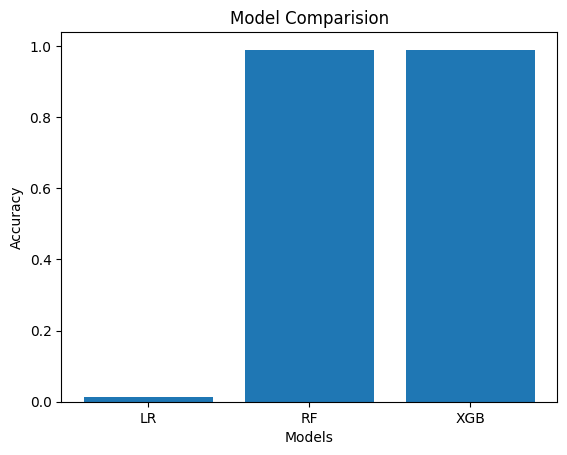

In [47]:
plt.bar(models, accuracy)

plt.title("Model Comparision")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [48]:
scores = cross_val_score(rf, X, y, cv=5)

print(scores)
print(scores.mean())

[0.98638572 0.93835523 0.96551724 0.66947181 0.58258073]
0.8284621457893369


In [49]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}
